# Translation Integration

Translate transcription segments from source to target language using **argostranslate** (offline, OpenNMT-based).

Key limitation: argostranslate has **no duration budget** — the translation length is unconstrained.
Romance languages (Spanish, French, Italian) typically produce longer text than the English source,
which creates timing challenges for the downstream TTS stage.

## Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

class _NoopSpan:
    def __enter__(self): return self
    def __exit__(self, *a): pass
class _noop:
    @staticmethod
    def span(name, **kw): return _NoopSpan()
    @staticmethod
    def info(*a, **kw): pass
logfire = _noop()

video_id = "GYQ5yGV_-Oc"
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers


## Run Translation

In [2]:
import argostranslate.package
import argostranslate.translate

# Install EN->ES package if not already installed
argostranslate.package.update_package_index()
available = argostranslate.package.get_available_packages()
pkg = next(p for p in available if p.from_code == "en" and p.to_code == "es")
argostranslate.package.install_from_path(pkg.download())

# Load whisper segments
transcription_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
en_data = json.loads((transcription_dir / f"{video_id}.json").read_text())
en_segs = en_data["segments"]

# Translate each segment
es_segs = []
for seg in en_segs:
    translated = argostranslate.translate.translate(seg["text"], "en", "es")
    es_segs.append({**seg, "text": translated})

# Save to disk
translation_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"
translation_dir.mkdir(parents=True, exist_ok=True)
out = {"target_language": "es", "segments": es_segs}
(translation_dir / f"{video_id}.json").write_text(json.dumps(out, indent=2))

print(f"Translated {len(es_segs)} segments")
print("\nFirst 3 segments (EN -> ES):")
for i, (en, es) in enumerate(zip(en_segs[:3], es_segs[:3])):
    print(f"  EN: {en['text'].strip()}")
    print(f"  ES: {es['text'].strip()}")
    print()

/Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-02 20:43:24 WARNING: Language en package default expects mwt, which has been added


Translated 98 segments

First 3 segments (EN -> ES):
  EN: 60 minutes over time.
  ES: 60 minutos con el tiempo.

  EN: What's the worst case scenario that you're worried about?
  ES: ¿Cuál es el peor escenario que te preocupa?

  EN: Is that it is closed for weeks and weeks and weeks here and you start to see the global
  ES: Es que está cerrado durante semanas y semanas y semanas aquí y empiezas a ver el mundo



## Analyze Translation Length

Compare character counts between source and target segments.
Romance languages tend to produce longer text than English,
which matters for TTS duration budgets downstream.

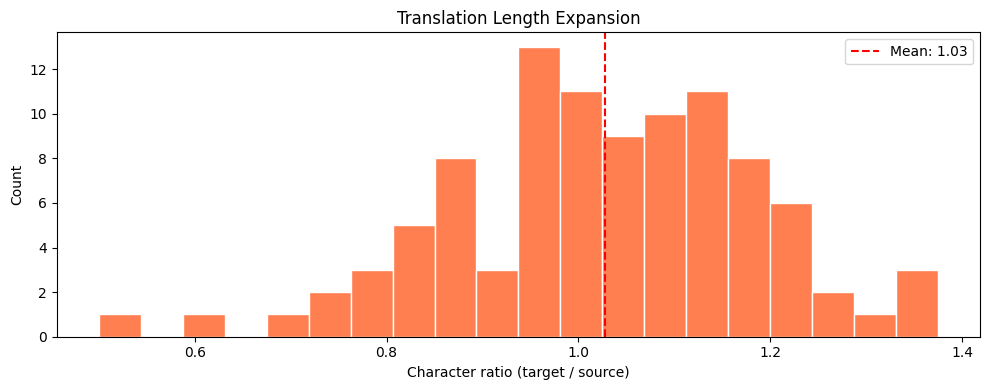

Mean ratio:   1.03
Median ratio: 1.04
Max ratio:    1.38


In [3]:
import matplotlib.pyplot as plt
import numpy as np

ratios = [len(es["text"]) / max(len(en["text"]), 1) for en, es in zip(en_segs, es_segs)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ratios, bins=20, color="coral", edgecolor="white")
ax.axvline(np.mean(ratios), color="red", linestyle="--", label=f"Mean: {np.mean(ratios):.2f}")
ax.set_xlabel("Character ratio (target / source)")
ax.set_ylabel("Count")
ax.set_title("Translation Length Expansion")
ax.legend()
fig.tight_layout()
fig.savefig(str(IMAGES_DIR / "translation_length_ratio.png"), dpi=150)
plt.show()

print(f"Mean ratio:   {np.mean(ratios):.2f}")
print(f"Median ratio: {np.median(ratios):.2f}")
print(f"Max ratio:    {np.max(ratios):.2f}")

## Duration-Aware Re-ranking (Student Assignment)

This corresponds to **P8** in the full pipeline notebook.

The function `get_shorter_translations()` in `foreign_whispers/reranking.py` is a **stub**
that currently returns an empty list. Students implement it to produce shorter
target-language translations that fit within a TTS duration budget.

See the docstring in `reranking.py` for the full specification, including:
- Input/output contract
- Duration heuristic (~15 chars/second for Romance languages)
- Suggested implementation approaches (rule-based, multi-backend, LLM, hybrid)

In [4]:
from foreign_whispers import get_shorter_translations, TranslationCandidate

# Demo the stub: pick a segment and request shorter translations
source_text = en_segs[0]["text"].strip()
baseline_es = es_segs[0]["text"].strip()
target_duration_s = 3.0

print(f"Source (EN):    {source_text}")
print(f"Baseline (ES):  {baseline_es}")
print(f"Duration budget: {target_duration_s}s (~{int(target_duration_s * 15)} chars at 15 chars/s)")
print()

candidates = get_shorter_translations(
    source_text=source_text,
    baseline_es=baseline_es,
    target_duration_s=target_duration_s,
)

print(f"Candidates returned: {len(candidates)}")
if candidates:
    for c in candidates:
        print(f"  [{c.char_count} chars] {c.text}  -- {c.brevity_rationale}")
else:
    print("  (empty list -- stub not yet implemented)")

Source (EN):    60 minutes over time.
Baseline (ES):  60 minutos con el tiempo.
Duration budget: 3.0s (~45 chars at 15 chars/s)

Candidates returned: 1
  [14 chars] 60 minutos más  -- retranslated from shortened English source (80% words)


## Summary

- Translation outputs are stored in `pipeline_data/api/translations/argos/`
- The segment format is preserved from the transcription stage, with the `text` field replaced by the translated text
- argostranslate produces unconstrained translations -- no duration budget is enforced
- Romance languages (e.g., Spanish) typically expand text length by ~10-30% vs. English
- The `get_shorter_translations()` stub in `foreign_whispers/reranking.py` is the extension point for duration-aware re-ranking